In [9]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


matplotlib.rcParams['date.converter'] = 'concise'
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.size'] = 12

Index(['South Bay', 'Point Loma', 'Encina'], dtype='object', name='location')


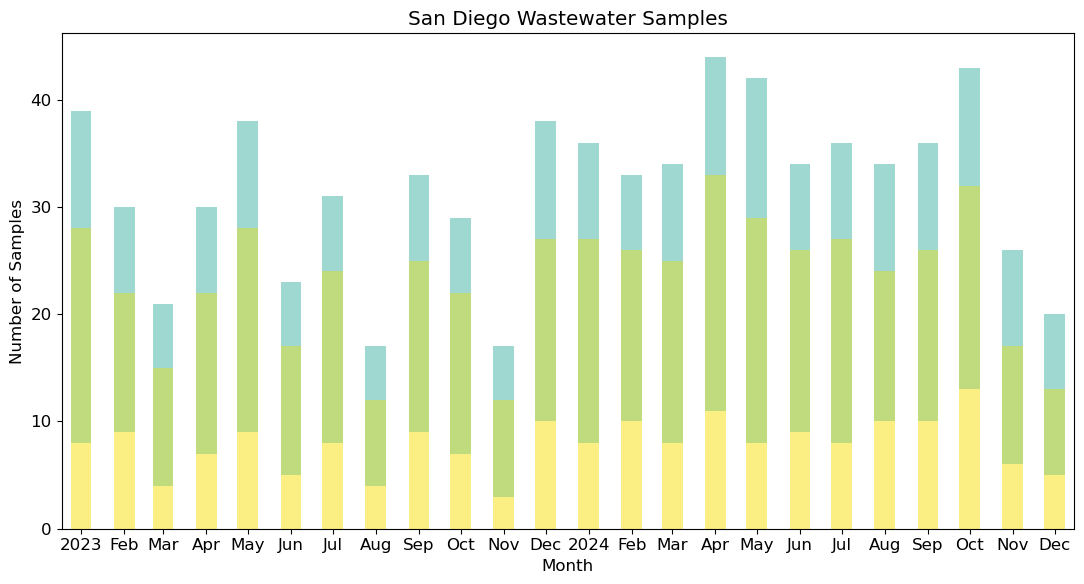

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

metadata = pd.read_csv('../data/search_metadata.csv')
metadata['collection_date'] = pd.to_datetime(metadata['collection_date'])
metadata = metadata[~metadata['sample'].str.contains('rerun|separate|combined', case=False, na=False)]
metadata = metadata.drop_duplicates(subset=['sample'])

metadata['month'] = metadata['collection_date'].dt.to_period('M').dt.to_timestamp()
location_monthly = metadata.groupby(['month', 'location']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#9FD8D0', '#C0DB7E', '#FBEE82'][::-1]

location_monthly = location_monthly[['South Bay', 'Point Loma', 'Encina']]
print(location_monthly.columns)
bottom = None
for i, location in enumerate(location_monthly.columns):
    ax.bar(
        location_monthly.index,
        location_monthly[location],
        bottom=bottom,
        color=colors[i % len(colors)],
        label=location,
        width=15,
    )
    bottom = location_monthly[location] if bottom is None else bottom + location_monthly[location]

# Format date axis
ax.set(xlim=(location_monthly.index.min() - pd.Timedelta(14, unit='D'), location_monthly.index.max() + pd.Timedelta(14, unit='D')))
locator = mdates.MonthLocator(bymonthday=1)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

# Labels and style
plt.title('San Diego Wastewater Samples')
plt.xlabel('Month')
plt.ylabel('Number of Samples')
plt.tight_layout()

# Save and show
plt.savefig('wastewater_samples.pdf', bbox_inches='tight', transparent=True)
plt.show()


In [11]:
# Get handles and labels from the main axis
handles, labels = ax.get_legend_handles_labels()

handles = handles[::-1]
labels = labels[::-1]
# Create a new figure for the legend
fig_legend = plt.figure(figsize=(3, 2))
fig_legend.legend(
    handles,
    labels,
    title="Location",
    loc='center',
    frameon=True
)

# Remove all axes
fig_legend.gca().axis('off')

# Save legend as PDF
fig_legend.savefig('wastewater_legend.pdf', bbox_inches='tight', transparent=True)
plt.close(fig_legend)

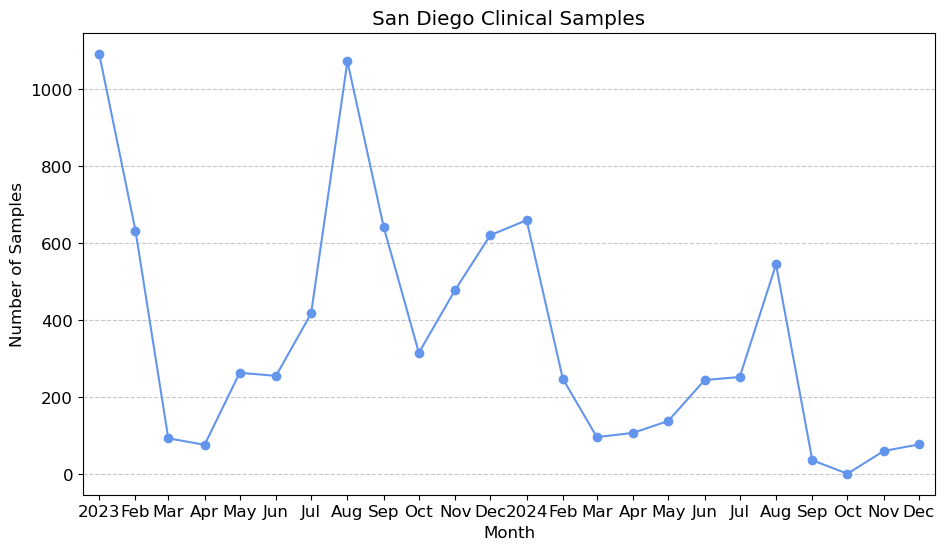

In [12]:
# Plot clinical data over study period

clinical = pd.read_csv('sd_clinical_samples.tsv', sep='\t')
clinical['collection_date'] = pd.to_datetime(clinical['collection_date'])

clinical = clinical[
    (clinical['collection_date'] >= "2023-01-01") &
    (clinical['collection_date'] <= "2024-12-31")
]

# bin by month, and make line plot
clinical['month'] = clinical['collection_date'].dt.to_period('M').dt.to_timestamp()
clinical_monthly = clinical.groupby('month').size()
fig, ax = plt.subplots(figsize=(11, 6))

plt.title('San Diego Clinical Samples')
plt.xlabel('Month')
plt.ylabel('Number of Samples')

# set x limits to match wastewater plot
ax.set(xlim=(location_monthly.index.min() - pd.Timedelta(14, unit='D'), location_monthly.index.max() + pd.Timedelta(14, unit='D')))


# add gridlines
ax.grid(visible=True, which='major', axis='y', linestyle='--', alpha=0.7)
ax.plot(
    clinical_monthly.index,
    clinical_monthly.values,
    marker='o',
    color='cornflowerblue',
)

locator = mdates.MonthLocator(bymonthday=1)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

plt.savefig('clinical_samples.pdf', bbox_inches='tight', transparent=True)